In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)

In [3]:
SEED = 42

import os
import random
import numpy as np

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [4]:
DATA_PATH = "train_2.csv"

df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
print("columns:", list(df.columns))
display(df.head(5))
df.info()

shape: (485082, 24)
columns: ['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия, категориальный', 'Торговая площадь, категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 'Трафик авто, в час', 'Маркетплейсы, доставки, постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии', 'РТО']


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74209339.11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485082 entries, 0 to 485081
Data columns (total 24 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   new_id                                     485082 non-null  int64  
 1   Год                                        485082 non-null  int64  
 2   Месяц                                      485082 non-null  int64  
 3   Среднее количество промо товаров в чеке    485082 non-null  float64
 4   Среднее количество товаров в чеке          485082 non-null  float64
 5   Среднее количество отмен                   485082 non-null  float64
 6   Рабочие часы в день                        485082 non-null  float64
 7   Дата открытия, категориальный              485082 non-null  object 
 8   Торговая площадь, категориальный           485082 non-null  object 
 9   Населенный пункт                           485082 non-null  object 
 10  Регион  

In [5]:
display(df)

,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,7.514774e+07
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,7.491475e+07
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,8.712551e+07
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,8.265980e+07
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,7.420934e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485077,21745,2023,10,1.09,6.21,860.0,9.0,Средний по возрасту,Большой,Павловский Посад г,Московская обл,69808,3121,114,204,5,2,2,4,3,3,13,1,1.800939e+08
485078,21745,2024,11,0.91,6.21,1226.0,9.0,Средний по возрасту,Большой,Павловский Посад г,Московская обл,69808,3121,114,204,5,2,2,4,3,3,13,1,2.074941e+08
485079,21745,2023,11,1.16,6.36,755.0,9.0,Средний по возрасту,Большой,Павловский Посад г,Московская обл,69808,3121,114,204,5,2,2,4,3,3,13,1,1.792471e+08
485080,21745,2023,12,1.29,6.97,802.0,9.0,Средний по возрасту,Большой,Павловский Посад г,Московская обл,69808,3121,114,204,5,2,2,4,3,3,13,1,2.163958e+08


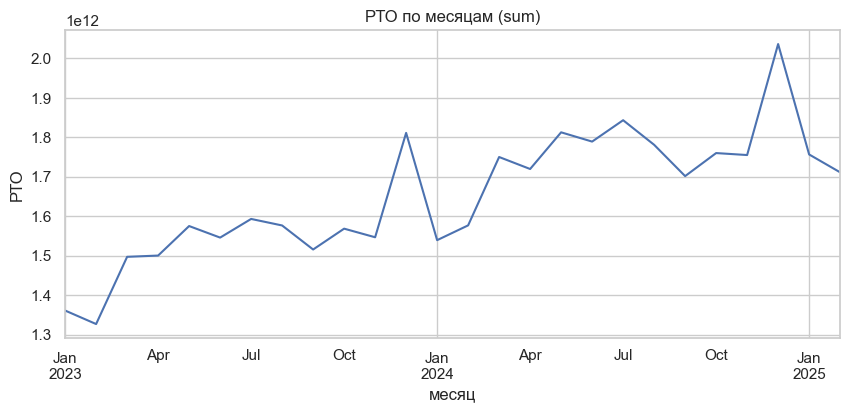

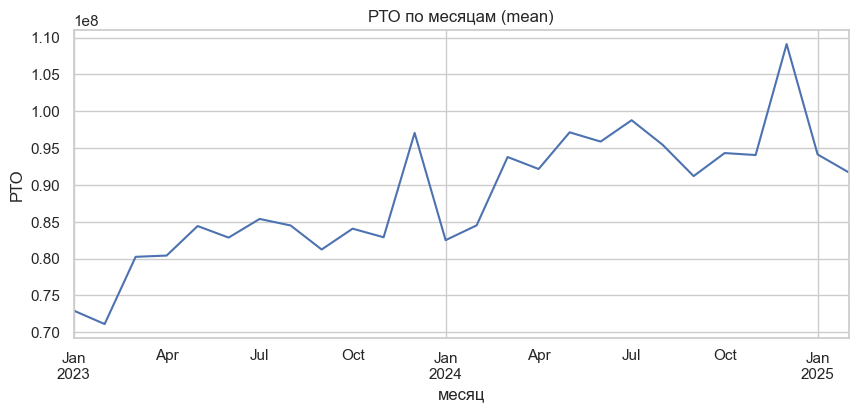

In [6]:
def plot_target_series(df, year_col="Год", month_col="Месяц", target_col="РТО", agg="sum"):
    data = df[[year_col, month_col, target_col]].copy()
    data["_date"] = pd.to_datetime(
        data[year_col].astype(int).astype(str)
        + "-"
        + data[month_col].astype(int).astype(str).str.zfill(2)
        + "-01",
        errors="coerce",
    )
    data = data.dropna(subset=["_date"])

    grouped = data.groupby("_date")[target_col]
    if agg == "sum":
        series = grouped.sum()
    elif agg == "mean":
        series = grouped.mean()
    elif agg == "median":
        series = grouped.median()
    else:
        raise ValueError("agg должен быть: sum, mean или median")

    series = series.sort_index()
    ax = series.plot(figsize=(10, 4))
    ax.set_title(f"{target_col} по месяцам ({agg})")
    ax.set_xlabel("месяц")
    ax.set_ylabel(target_col)
    plt.show()
    return series

rto_series = plot_target_series(df, year_col="Год", month_col="Месяц", target_col="РТО", agg="sum")
rto_series = plot_target_series(df, year_col="Год", month_col="Месяц", target_col="РТО", agg="mean")

In [7]:
numeric_cols = [i for i in df.select_dtypes(include=[np.number]).columns.tolist() if i != 'new_id']

categorical_cols = [c for c in df.columns if c not in numeric_cols]

print("числовые колонки:", len(numeric_cols))
print("категориальные колонки:", len(categorical_cols))

числовые колонки: 19
категориальные колонки: 5


## 4. Качество данных
Пропуски, дубликаты и кардинальность категорий.

In [8]:
missing = df.isna().mean().sort_values(ascending=False)
print("доля дублей:", df.duplicated().mean())

print("\nТоп по доле пропусков")
display(missing.head(20))

if (missing > 0).any():
    top_missing = missing[missing > 0].head(20)
    ax = top_missing[::-1].plot(kind="barh")
    ax.set_title("Топ пропусков")
    ax.set_xlabel("доля пропусков")
    plt.show()

if categorical_cols:
    cat_card = df[categorical_cols].nunique().sort_values(ascending=False)
    print("\nКардинальность категорий")
    display(cat_card.head(20))

доля дублей: 0.0

Топ по доле пропусков


new_id                                       0.0
Год                                          0.0
Флаг алкогольной лицензии                    0.0
Количество касс                              0.0
Пятерочки (500 м)                            0.0
Продуктовые магазины (500 м)                 0.0
Остановки (300 м)                            0.0
Школы (300 м)                                0.0
Медицинские уч. и аптеки (300 м)             0.0
Маркетплейсы, доставки, постаматы (100 м)    0.0
Трафик авто, в час                           0.0
Трафик пеший, в час                          0.0
Количество домохозяйств                      0.0
Численность населения                        0.0
Регион                                       0.0
Населенный пункт                             0.0
Торговая площадь, категориальный             0.0
Дата открытия, категориальный                0.0
Рабочие часы в день                          0.0
Среднее количество отмен                     0.0
dtype: float64


Кардинальность категорий


new_id                              18657
Населенный пункт                     3270
Регион                                 67
Торговая площадь, категориальный        4
Дата открытия, категориальный           3
dtype: int64

## 4.1 Распределение всех числовых колонок
Гистограммы по каждой числовой колонке 

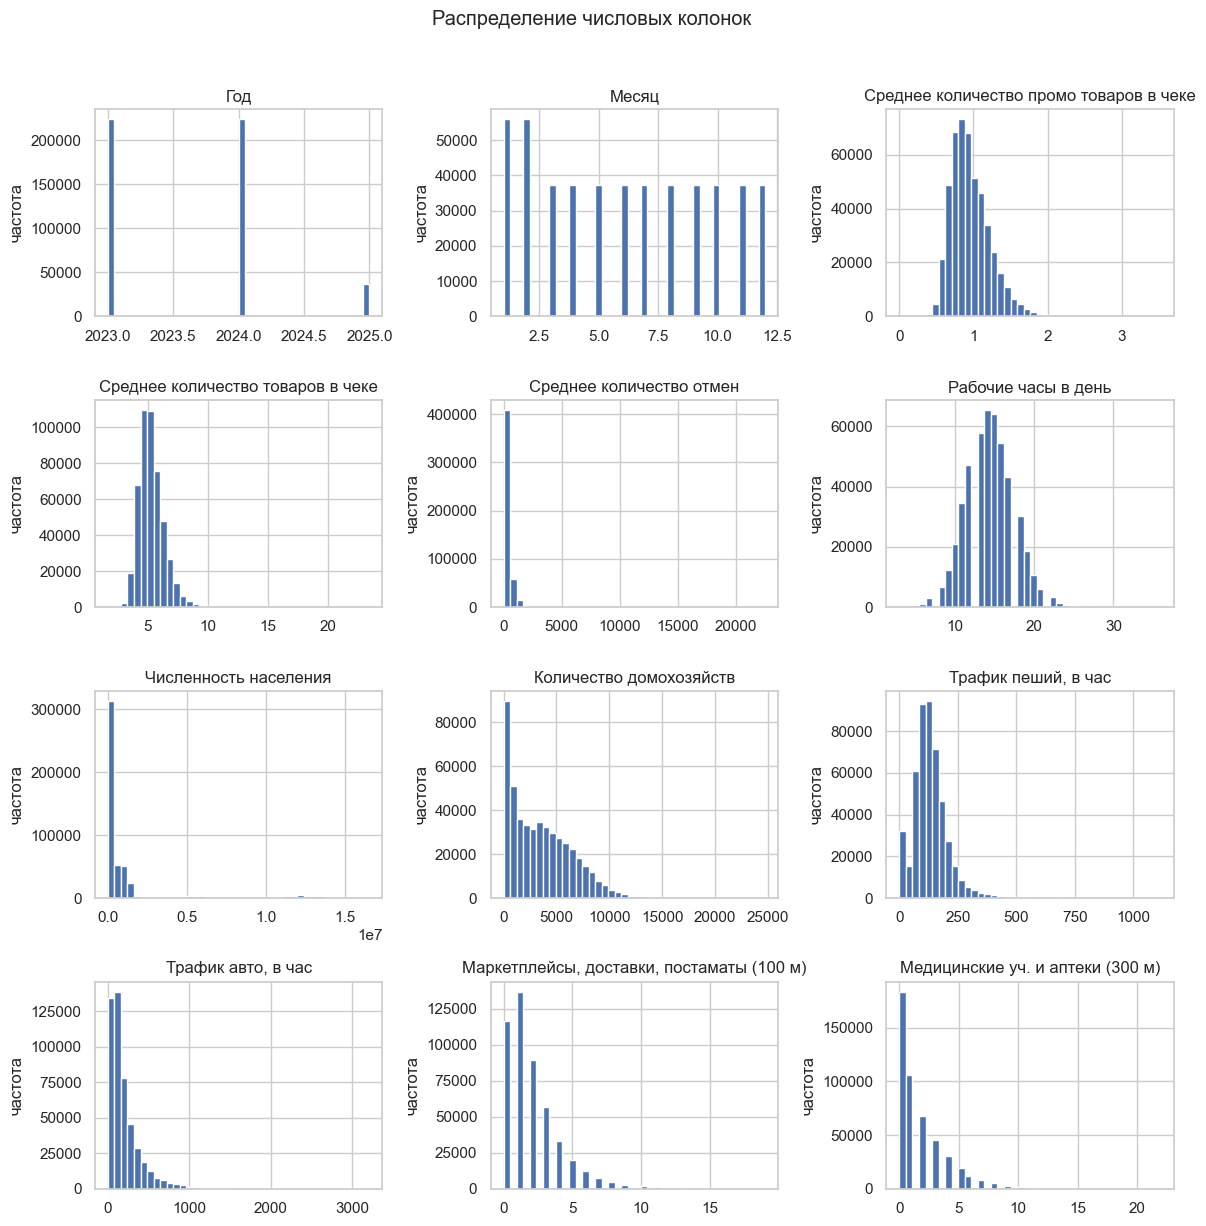

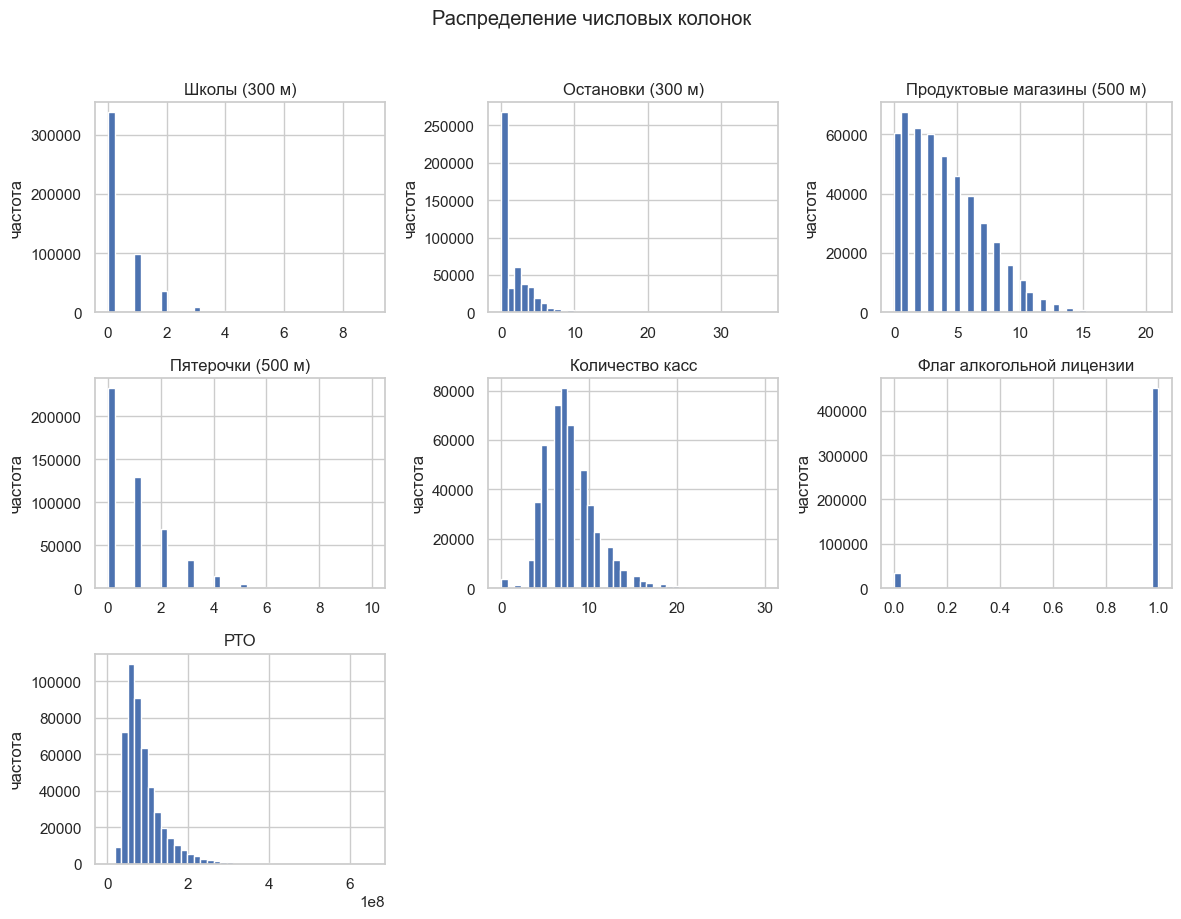

In [37]:
cols = [c for c in numeric_cols if c in df.columns]
cols_per_page = 12
n_bins = 40

for start in range(0, len(cols), cols_per_page):
    chunk = cols[start : start + cols_per_page]
    n = len(chunk)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, chunk):
        series = df[col].dropna()
        ax.hist(series, bins=n_bins)
        ax.set_title(col)
        ax.set_ylabel("частота")
    for ax in axes[len(chunk):]:
        ax.axis("off")
    fig.suptitle("Распределение числовых колонок", y=1.02)
    plt.tight_layout()
    plt.show()

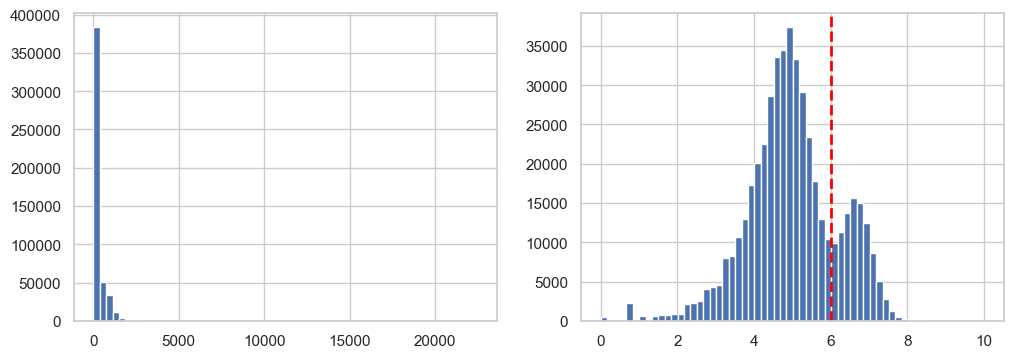

In [46]:
df['Среднее количество отмен LOG'] = np.log1p(df['Среднее количество отмен'])
threshold = 6
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Среднее количество отмен'], bins=60)
axes[1].hist(df['Среднее количество отмен LOG'], bins=60)
axes[1].axvline(threshold, color="red", linestyle="--", linewidth=2)

Это лик, пока для еда оставим 

*идея - обучим модель классификации которая будет таргетом как раз предсказывать 

In [47]:
df['is_high_cancel_cluster'] = (df['Среднее количество отмен LOG'] > threshold).astype(int)

In [50]:
high_cancel_df = df[df['is_high_cancel_cluster'] == 1]
normal_df = df[df['is_high_cancel_cluster'] == 0]

print(f"Размер обычного кластера (0): {len(normal_df)} записей")
print(f"Размер кластера высоких отмен (1): {len(high_cancel_df)} записей\n")

rto_stats = pd.DataFrame({
    'Кластер': ['Обычный (0)', 'Высокие отмены (1)'],
    'Медианный РТО (млн)': [
        normal_df['РТО'].median() / 1e6, 
        high_cancel_df['РТО'].median() / 1e6
    ]
})
display(rto_stats.round(2))

Размер обычного кластера (0): 387450 записей
Размер кластера высоких отмен (1): 97632 записей



,Кластер,Медианный РТО (млн)
0,Обычный (0),67.40
1,Высокие отмены (1),138.77


In [ ]:
test_period = df[(df['Год'] == 2025) & (df['Месяц'] == 3)].copy()
test_period.head()

,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО


In [55]:
print("\n2. Топ-5 Регионов в кластере ВЫСОКИХ отмен (доля внутри кластера):")
top_regions_high = (high_cancel_df['Регион'].value_counts(normalize=True).head(5) * 100).round(1).astype(str) + '%'
display(top_regions_high)

print("\nДля сравнения -> Топ-5 Регионов в ОБЫЧНОМ кластере:")
top_regions_normal = (normal_df['Регион'].value_counts(normalize=True).head(5) * 100).round(1).astype(str) + '%'
display(top_regions_normal)


2. Топ-5 Регионов в кластере ВЫСОКИХ отмен (доля внутри кластера):


Регион
Москва г              20.3%
Московская обл        13.4%
Санкт-Петербург г      8.6%
Краснодарский край     6.1%
Татарстан Респ         4.9%
Name: proportion, dtype: object


Для сравнения -> Топ-5 Регионов в ОБЫЧНОМ кластере:


Регион
Московская обл        8.6%
Краснодарский край    4.5%
Ростовская обл        4.2%
Татарстан Респ        4.2%
Свердловская обл      3.9%
Name: proportion, dtype: object

In [54]:
if 'Торговая площадь, категориальный' in df.columns:
    print("\nРаспределение торговой площади:")
    
    area_comparison = pd.DataFrame({
        'В высоких отменах (%)': (high_cancel_df['Торговая площадь, категориальный'].value_counts(normalize=True) * 100).round(1),
        'В обычных (%)': (normal_df['Торговая площадь, категориальный'].value_counts(normalize=True) * 100).round(1)
    }).fillna(0)
    
    display(area_comparison)


Распределение торговой площади:


,В высоких отменах (%),В обычных (%)
"Торговая площадь, категориальный",,
Большой,47.1,14.2
Маленький,6.0,24.5
Очень большой,10.8,0.5
Средний,36.1,60.8


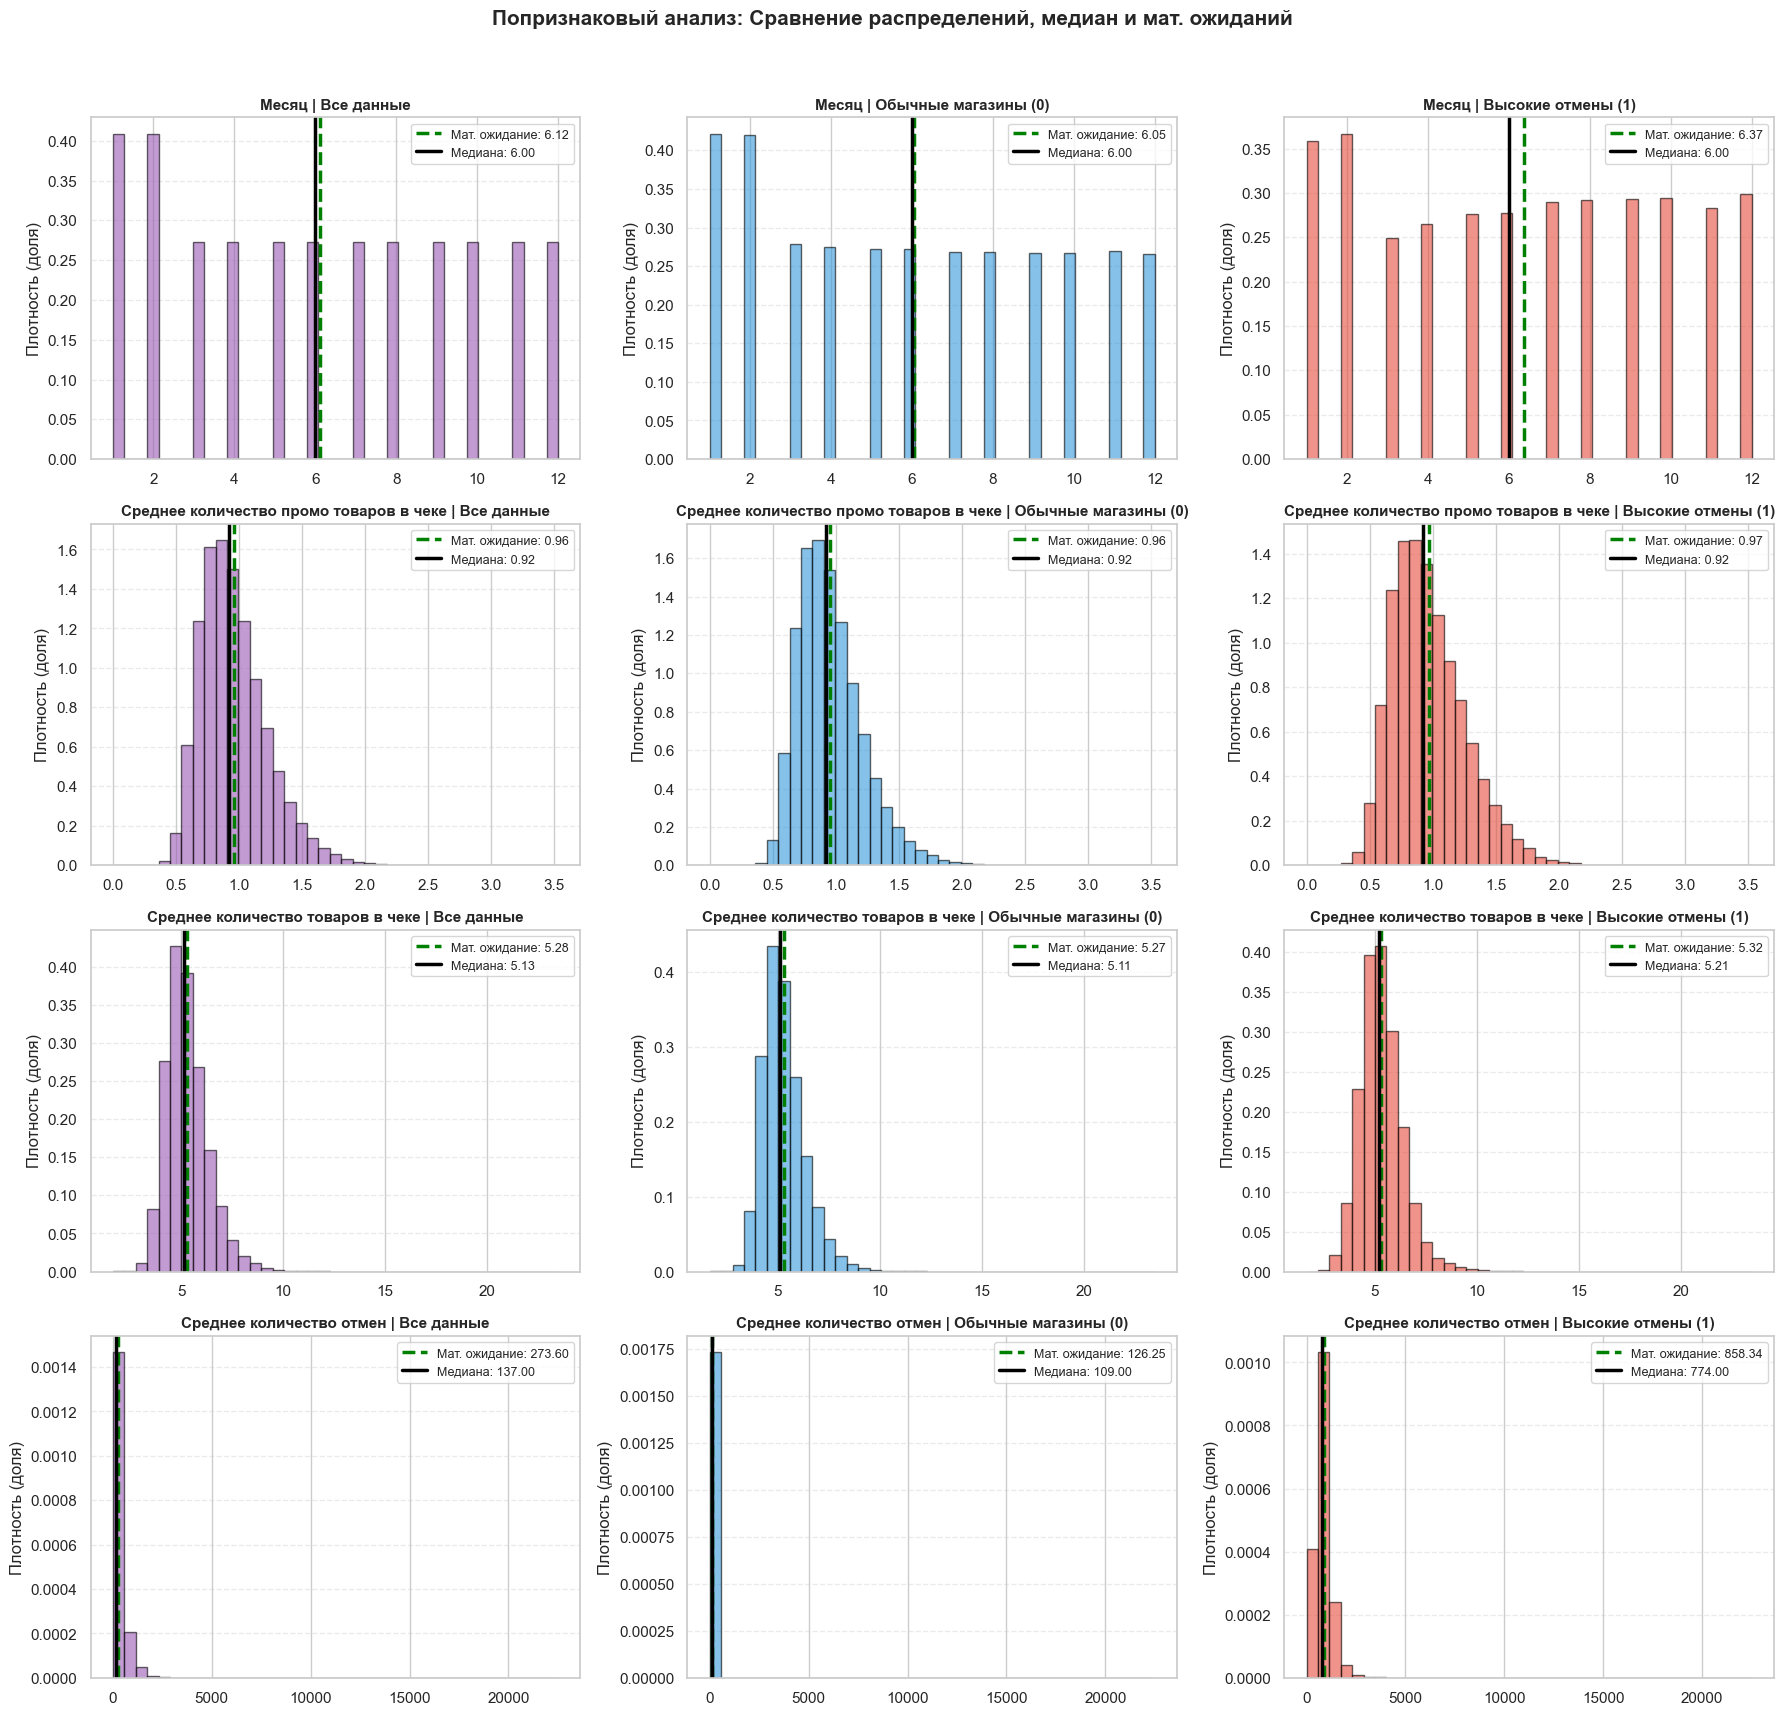

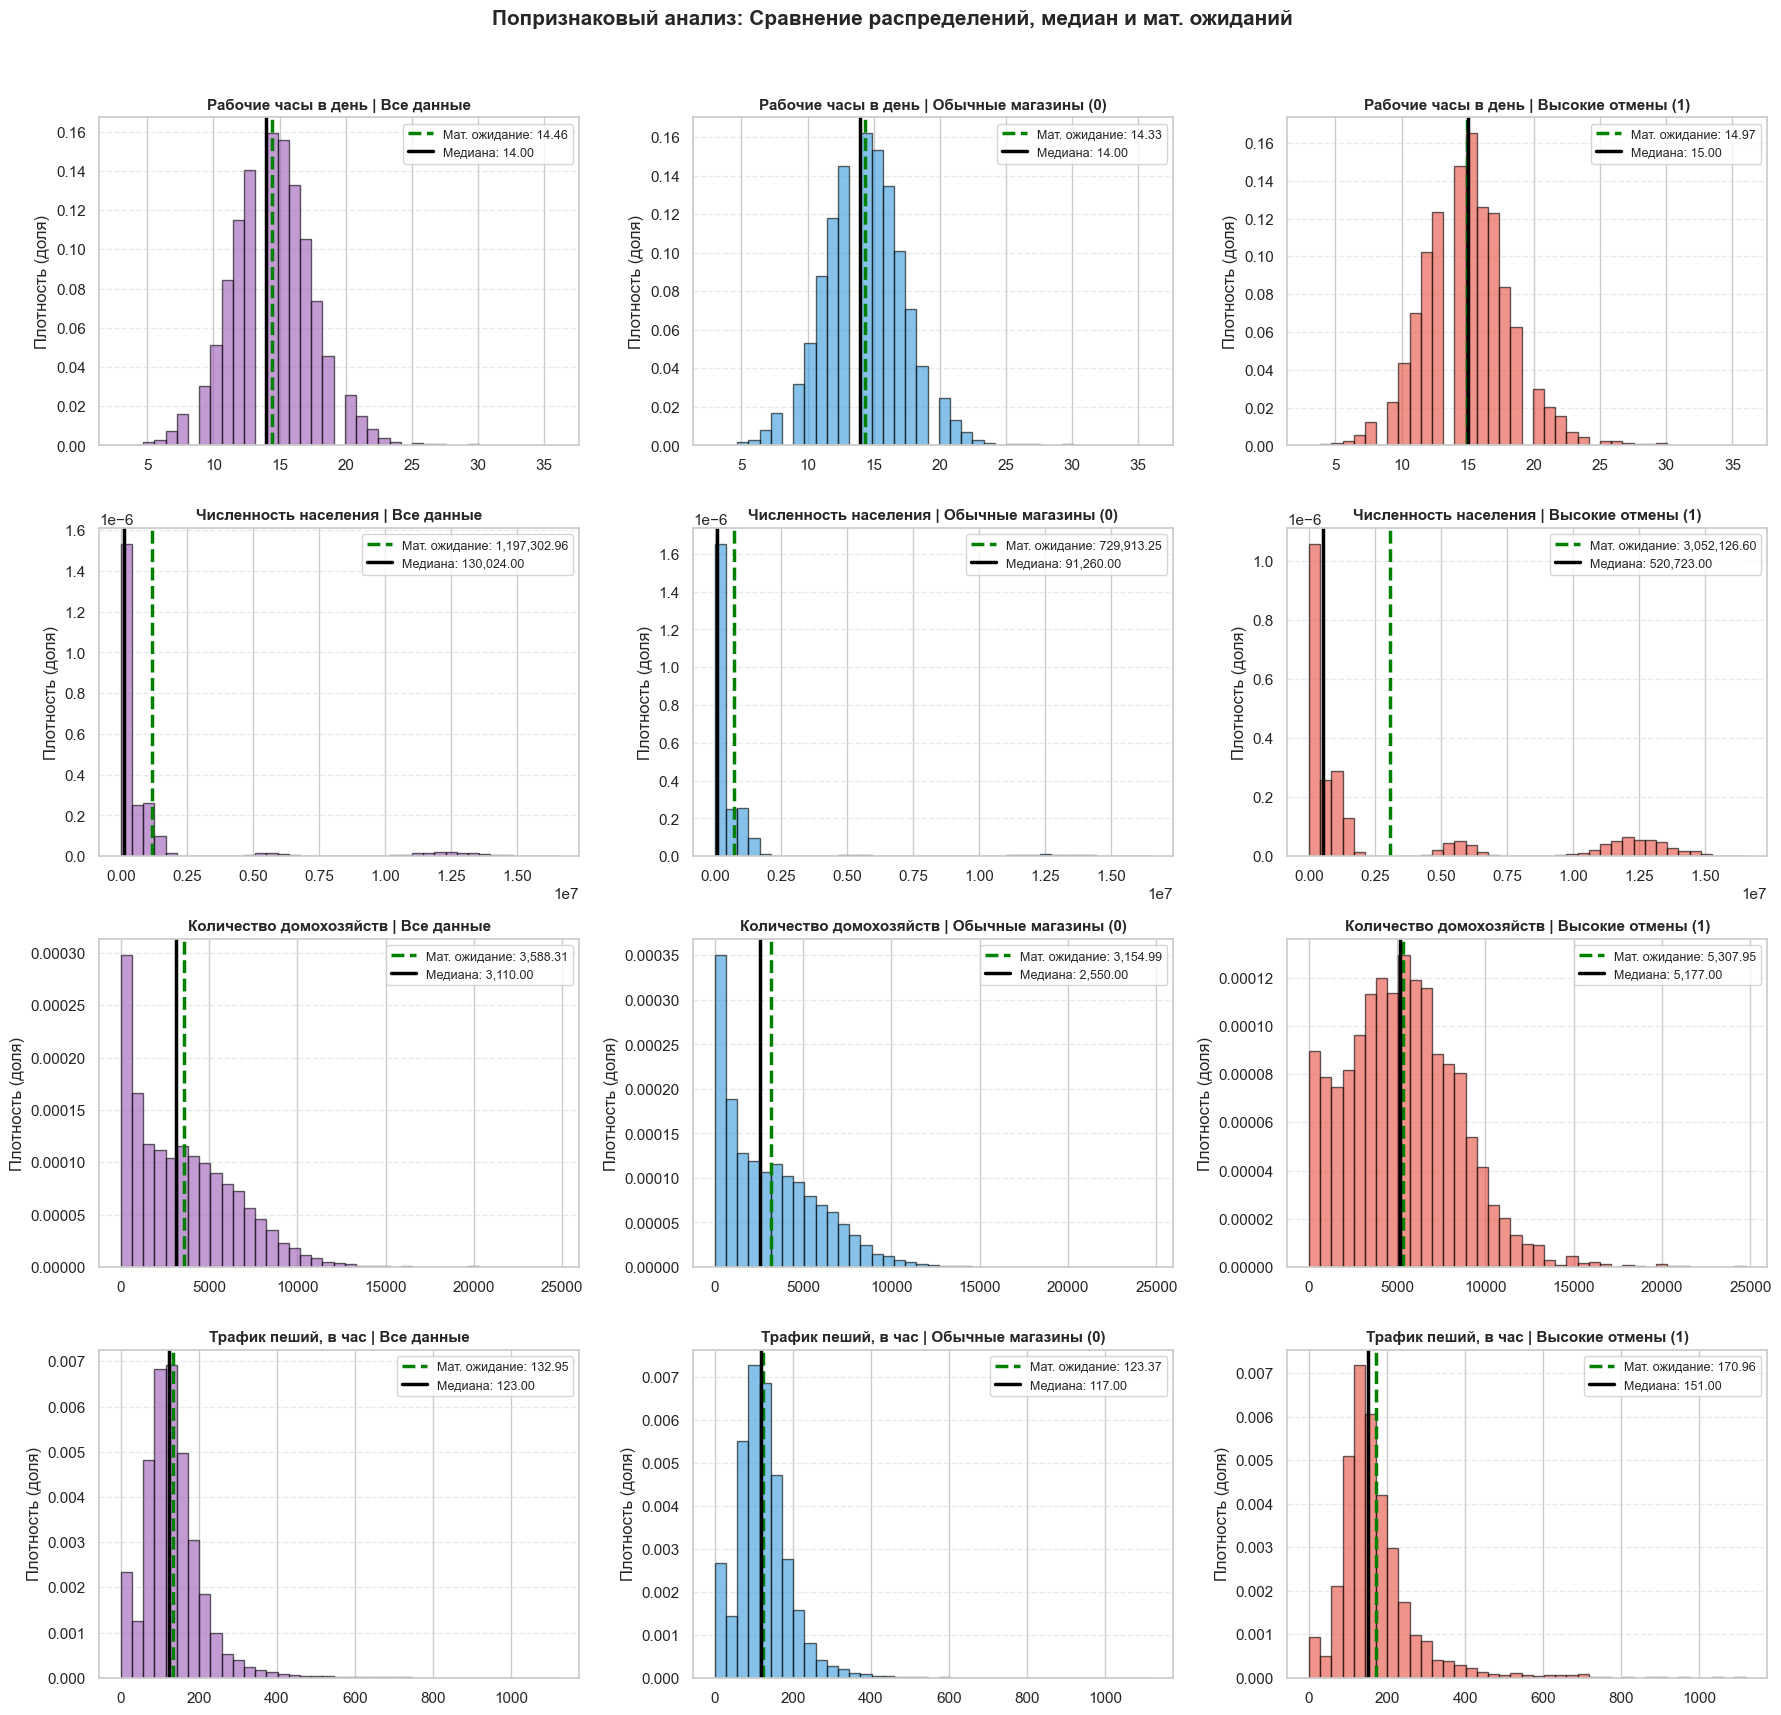

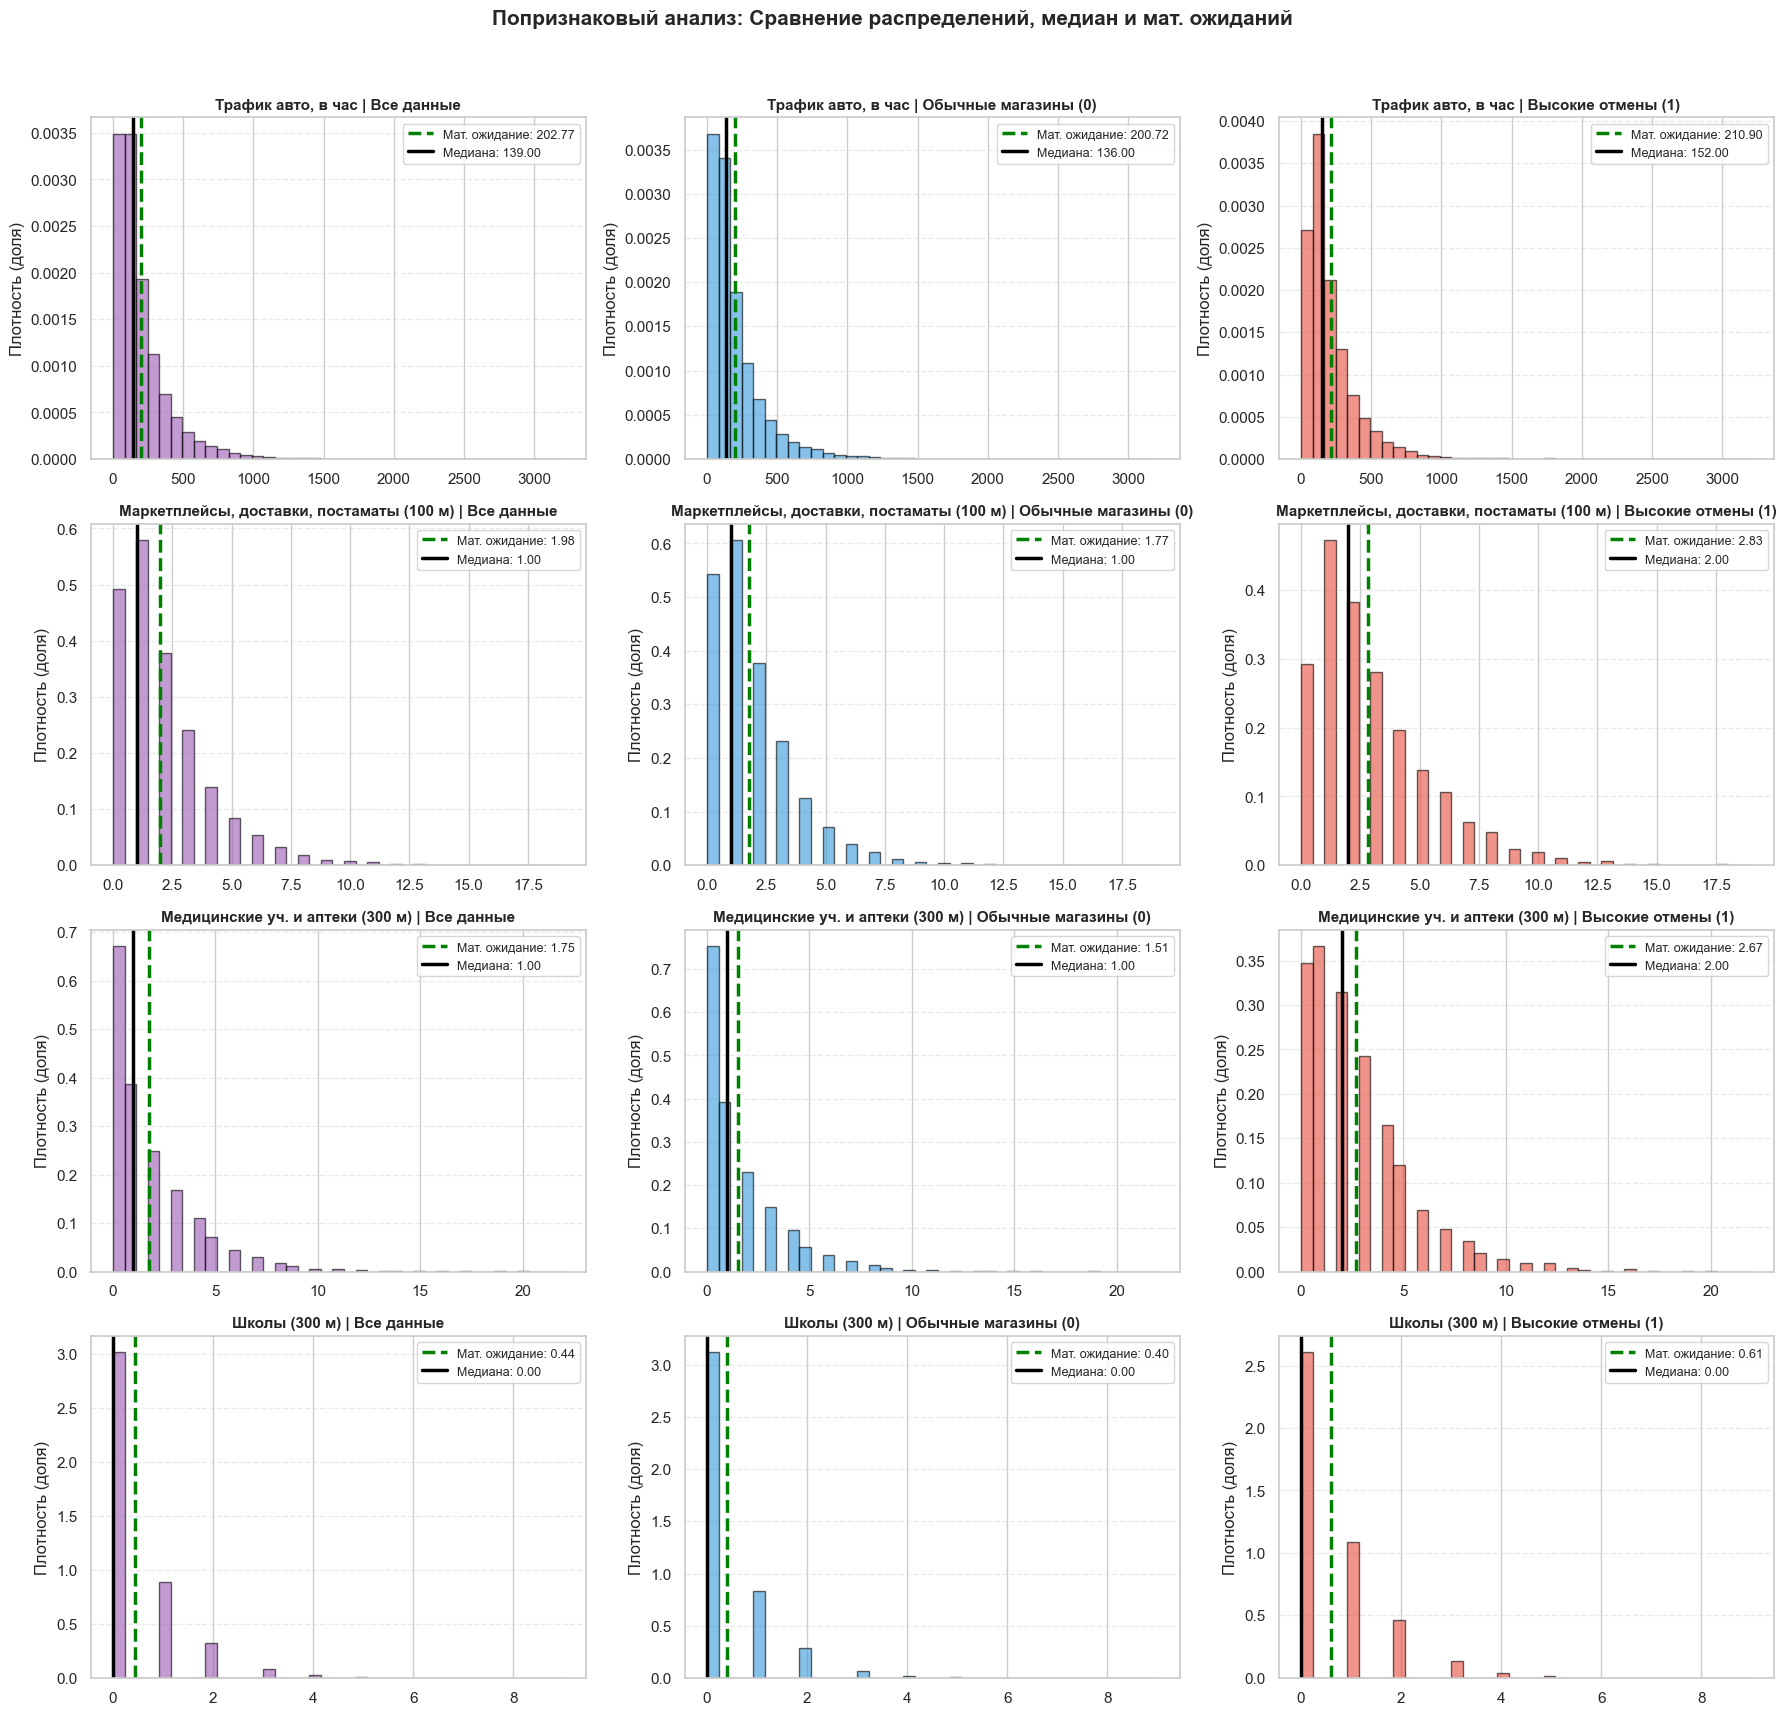

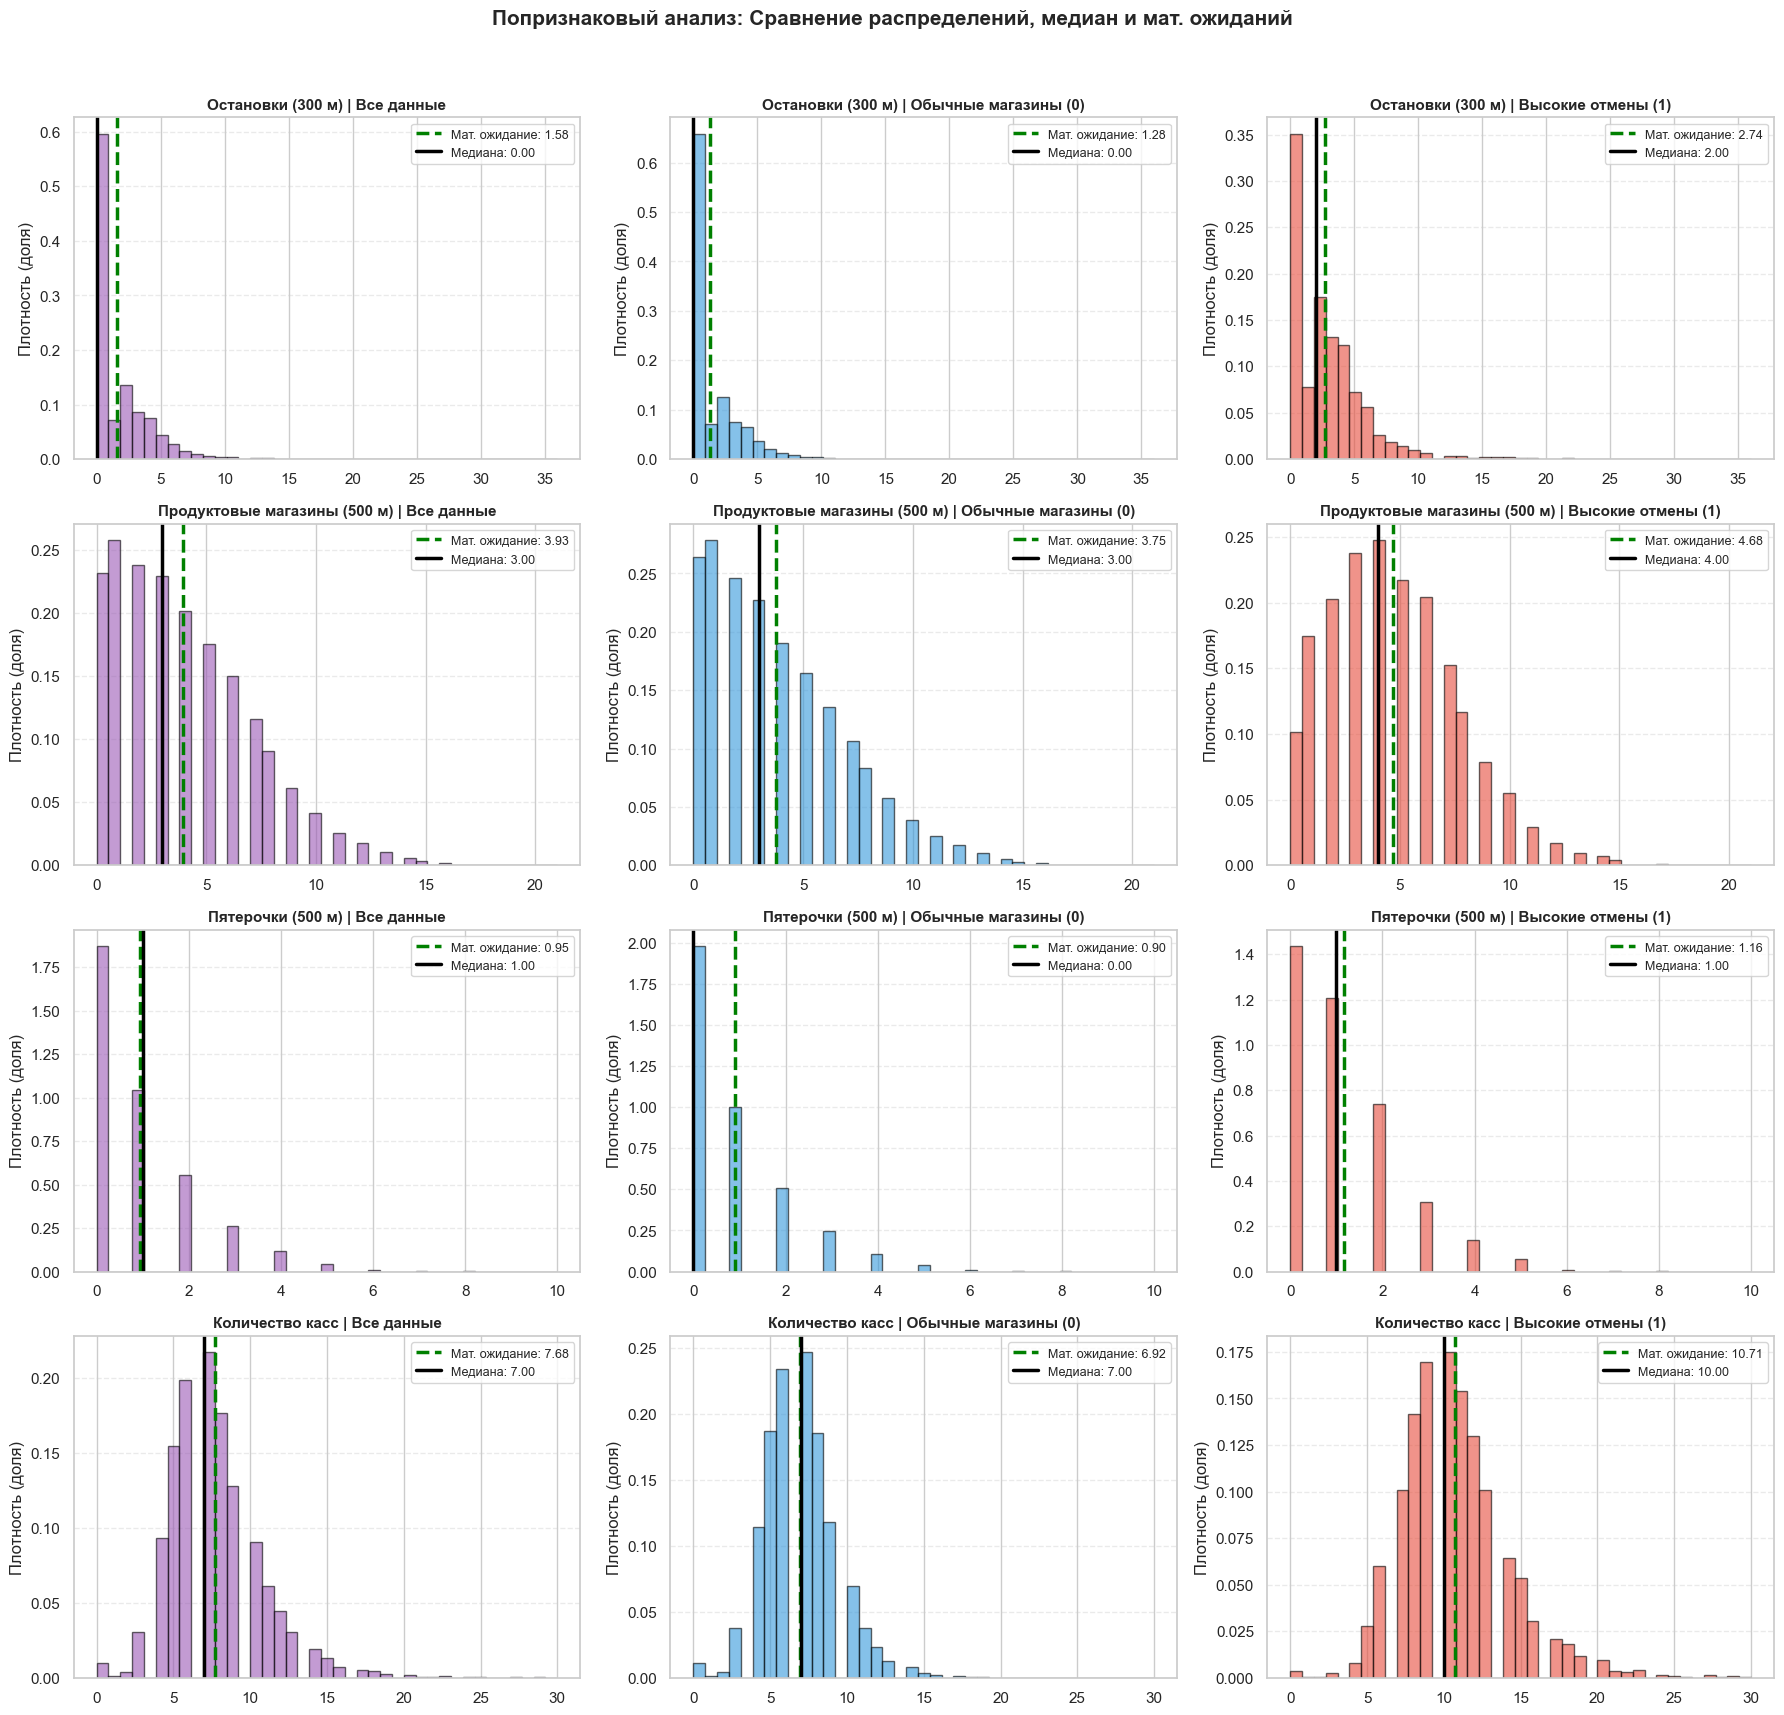

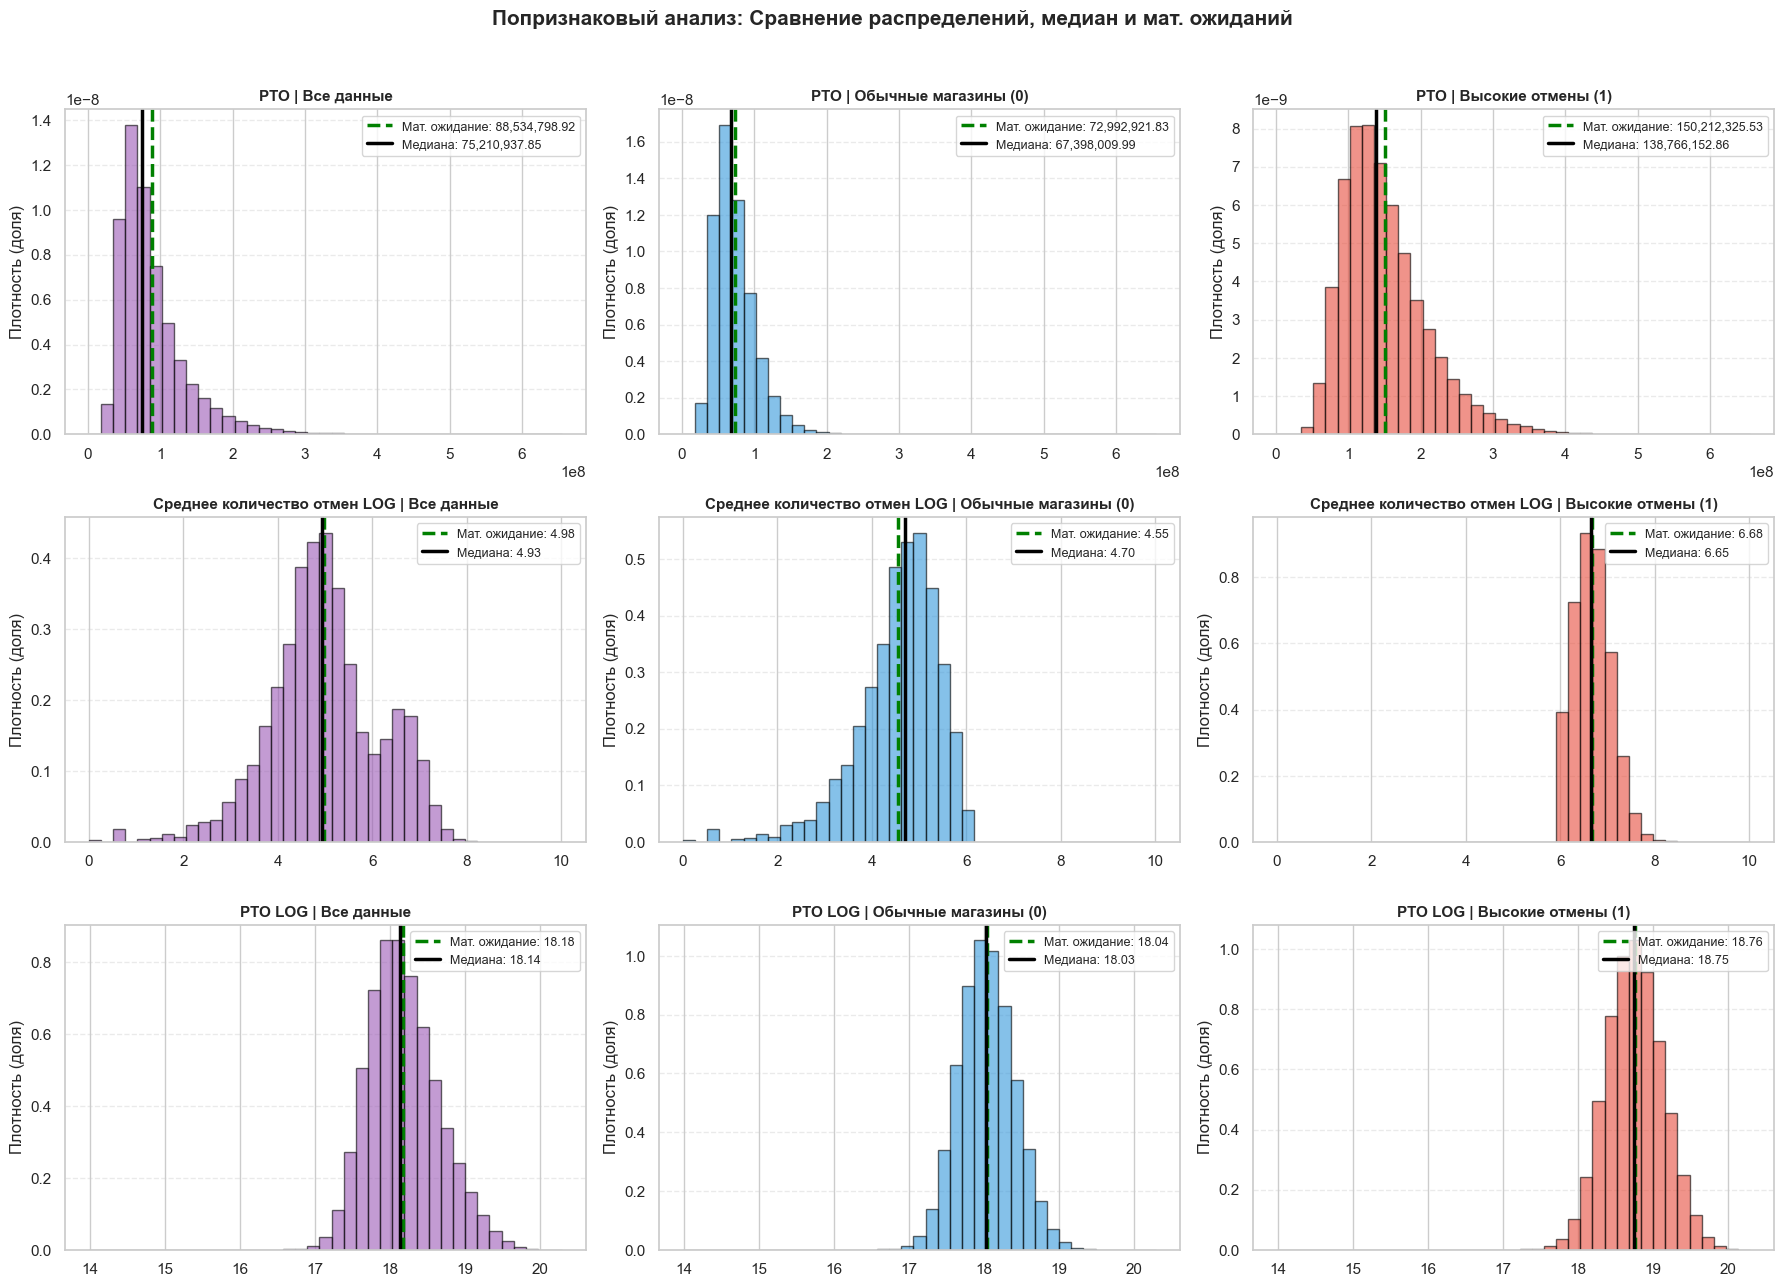

In [27]:
import matplotlib.pyplot as plt
import numpy as np

cols = [c for c in numeric_cols if c in df.columns]

cols_per_page = 4
n_bins = 40

for start in range(0, len(cols), cols_per_page):
    chunk = cols[start : start + cols_per_page]
    n_rows = len(chunk)
    n_cols = 3

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.2 * n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols)

    for i, col in enumerate(chunk):
        series_all = df[col].dropna()
        series_low = df[df['is_high_cancel_cluster'] == 0][col].dropna()
        series_high = df[df['is_high_cancel_cluster'] == 1][col].dropna()

        if series_all.empty:
            continue

        min_val, max_val = series_all.min(), series_all.max()
        bins_edges = np.linspace(min_val, max_val, n_bins)

        subplots_config = [
            (series_all, "Все данные", "#9b59b6"),
            (series_low, "Обычные магазины (0)", "#3498db"),
            (series_high, "Высокие отмены (1)", "#e74c3c"),
        ]

        for j, (data, title_suffix, color) in enumerate(subplots_config):
            ax = axes[i, j]

            ax.hist(data, bins=bins_edges, color=color, edgecolor='black', alpha=0.6, density=True)

            mean_val = data.mean()
            median_val = data.median()

            ax.axvline(mean_val, color='green', linestyle='--', linewidth=2.5, label=f'Мат. ожидание: {mean_val:,.2f}')
            ax.axvline(median_val, color='black', linestyle='-', linewidth=2.5, label=f'Медиана: {median_val:,.2f}')

            ax.set_title(f"{col} | {title_suffix}", fontsize=11, fontweight='bold')
            ax.set_ylabel("Плотность (доля)")
            ax.grid(axis='y', linestyle='--', alpha=0.4)
            ax.legend(fontsize=9, loc='upper right')

    fig.suptitle("Попризнаковый анализ: Сравнение распределений, медиан и мат. ожиданий", y=1.02, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [65]:
df['РТО LOG'] = np.log1p(df['РТО'])

In [74]:
exclude_cols = ['new_id', ]
numeric_cols = []
categorical_cols = []

# Автоматически разделяем признаки по типам данных
for col in df.columns:
    if col in exclude_cols:
        continue
    if df[col].dtype in ['object', 'category'] or df[col].nunique() < 5:
        categorical_cols.append(col)
    else:
        numeric_cols.append(col)

In [75]:
numeric_cols

['Месяц',
 'Среднее количество промо товаров в чеке',
 'Среднее количество товаров в чеке',
 'Среднее количество отмен',
 'Рабочие часы в день',
 'Численность населения',
 'Количество домохозяйств',
 'Трафик пеший, в час',
 'Трафик авто, в час',
 'Маркетплейсы, доставки, постаматы (100 м)',
 'Медицинские уч. и аптеки (300 м)',
 'Школы (300 м)',
 'Остановки (300 м)',
 'Продуктовые магазины (500 м)',
 'Пятерочки (500 м)',
 'Количество касс',
 'РТО',
 'Среднее количество отмен LOG',
 'РТО LOG']

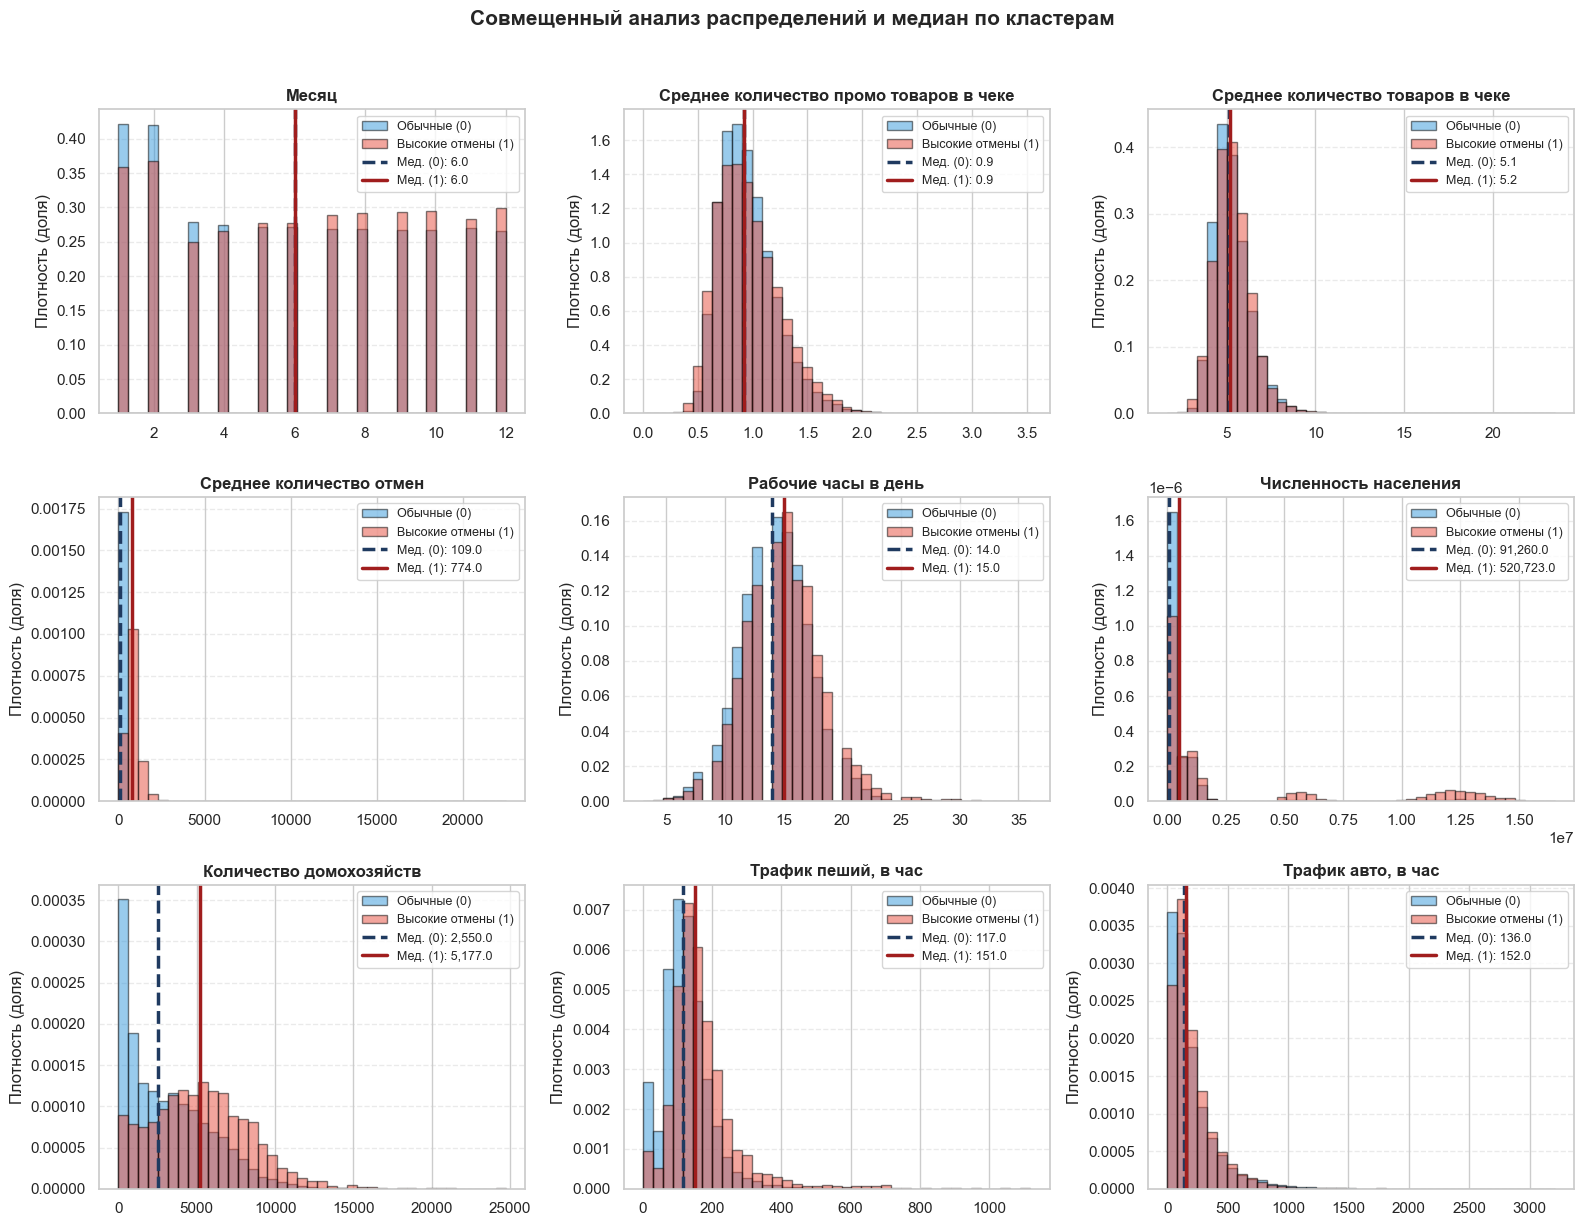

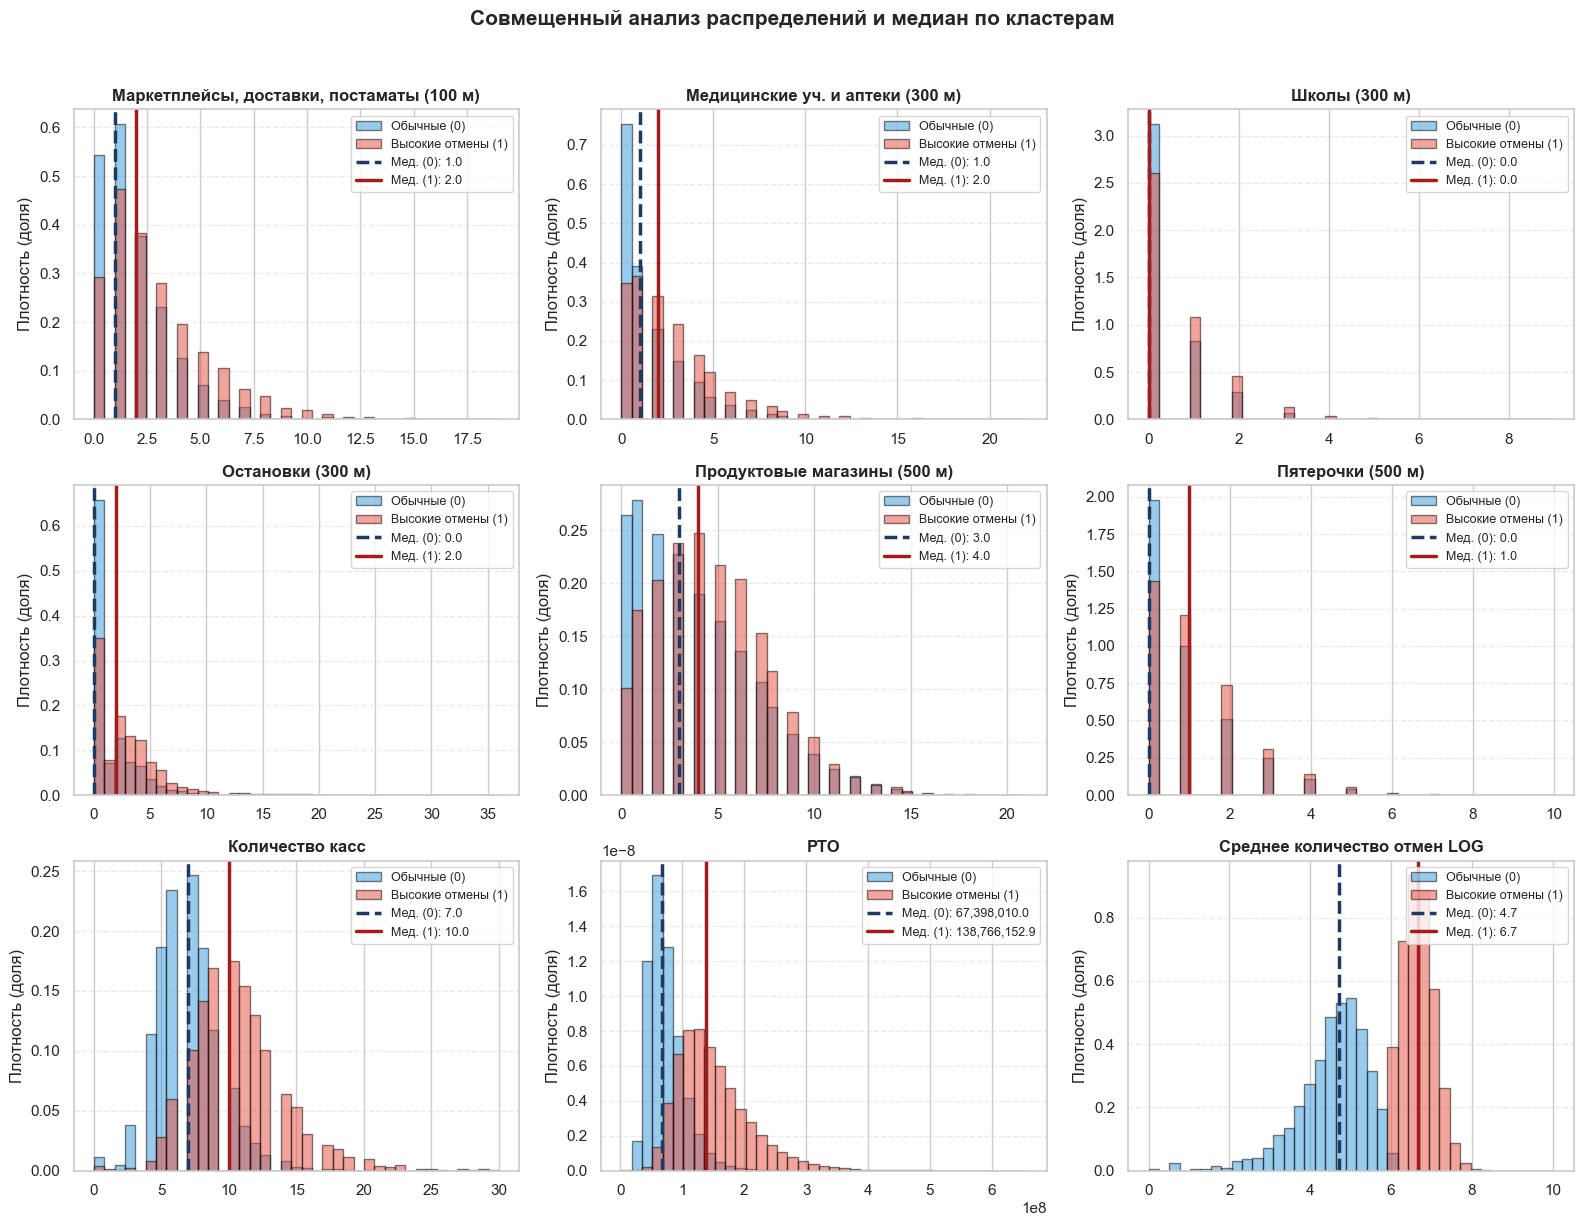

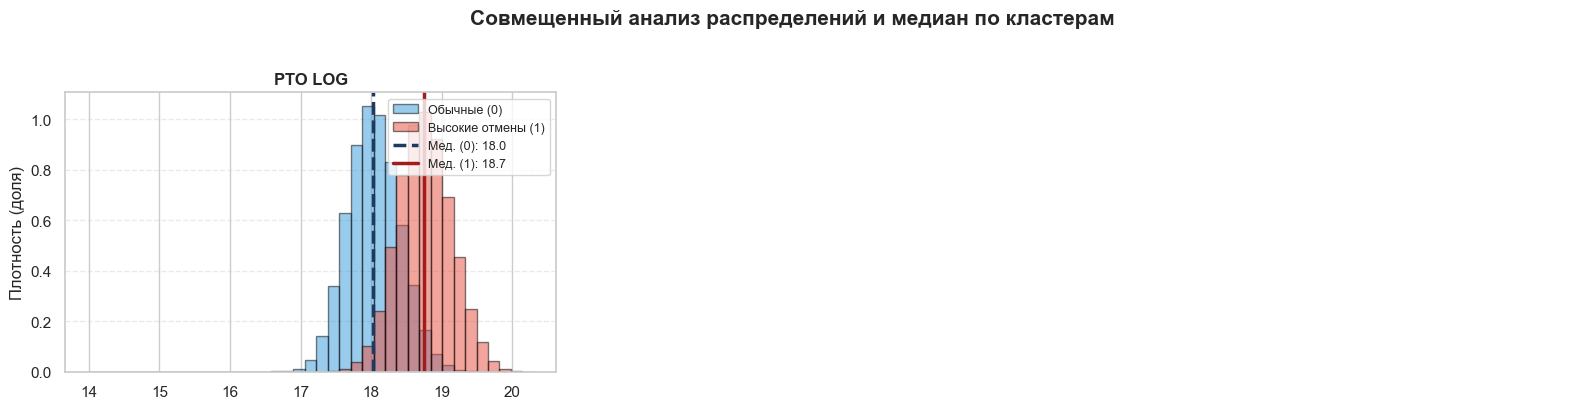

In [76]:
import matplotlib.pyplot as plt
import numpy as np

cols = [c for c in numeric_cols if c in df.columns]
cols_per_page = 9
n_bins = 40

for start in range(0, len(cols), cols_per_page):
    chunk = cols[start : start + cols_per_page]
    n = len(chunk)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, chunk):
        series_low = df[df['is_high_cancel_cluster'] == 0][col].dropna()
        series_high = df[df['is_high_cancel_cluster'] == 1][col].dropna()

        if series_low.empty and series_high.empty:
            continue

        min_val = min(series_low.min(), series_high.min()) if len(series_low) > 0 and len(series_high) > 0 else 0
        max_val = max(series_low.max(), series_high.max()) if len(series_low) > 0 and len(series_high) > 0 else 1
        bins_edges = np.linspace(min_val, max_val, n_bins)

        ax.hist(series_low, bins=bins_edges, color='#3498db', alpha=0.5, edgecolor='black', density=True, label='Обычные (0)')
        ax.hist(series_high, bins=bins_edges, color='#e74c3c', alpha=0.5, edgecolor='black', density=True, label='Высокие отмены (1)')

        med_low = series_low.median()
        med_high = series_high.median()

        ax.axvline(med_low, color='#1f3a60', linestyle='--', linewidth=2.5, label=f'Мед. (0): {med_low:,.1f}')
        ax.axvline(med_high, color='#a01d1d', linestyle='-', linewidth=2.5, label=f'Мед. (1): {med_high:,.1f}')

        ax.set_title(col, fontsize=12, fontweight='bold')
        ax.set_ylabel("Плотность (доля)")
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.legend(fontsize=9, loc='upper right')

    for ax in axes[len(chunk):]:
        ax.axis("off")

    fig.suptitle("Совмещенный анализ распределений и медиан по кластерам", y=1.02, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

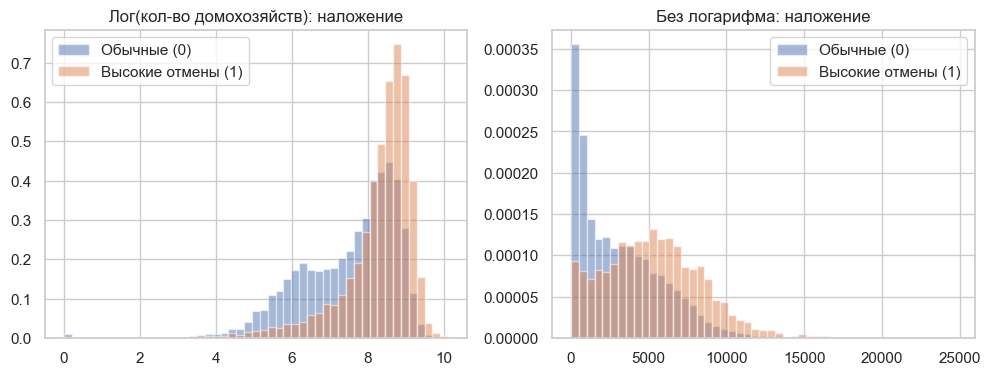

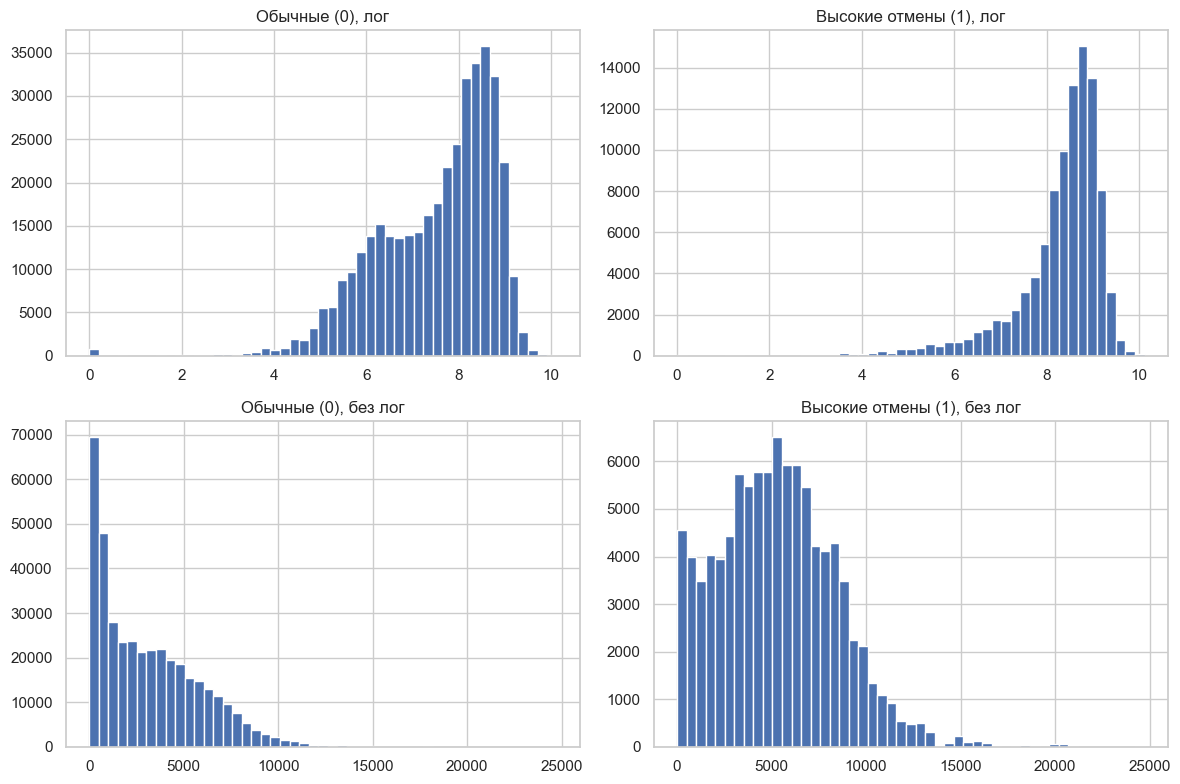

In [25]:
def _find_household_col(cols):
    matches = [c for c in cols if "домохозяй" in c.lower()]
    if not matches:
        raise ValueError("Не найдена колонка с количеством домохозяйств")
    return matches[0]

household_col = _find_household_col(df.columns)

s0_raw = df.loc[df["is_high_cancel_cluster"] == 0, household_col].dropna()
s1_raw = df.loc[df["is_high_cancel_cluster"] == 1, household_col].dropna()

df["_household_log"] = np.log1p(df[household_col])
s0_log = df.loc[df["is_high_cancel_cluster"] == 0, "_household_log"].dropna()
s1_log = df.loc[df["is_high_cancel_cluster"] == 1, "_household_log"].dropna()

if s0_raw.empty or s1_raw.empty:
    raise ValueError("Пустые данные для одного из кластеров")

bins_log = np.linspace(min(s0_log.min(), s1_log.min()), max(s0_log.max(), s1_log.max()), 50)
bins_raw = np.linspace(min(s0_raw.min(), s1_raw.min()), max(s0_raw.max(), s1_raw.max()), 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(s0_log, bins=bins_log, alpha=0.5, density=True, label="Обычные (0)")
axes[0].hist(s1_log, bins=bins_log, alpha=0.5, density=True, label="Высокие отмены (1)")
axes[0].set_title("Лог(кол-во домохозяйств): наложение")
axes[0].legend()
axes[1].hist(s0_raw, bins=bins_raw, alpha=0.5, density=True, label="Обычные (0)")
axes[1].hist(s1_raw, bins=bins_raw, alpha=0.5, density=True, label="Высокие отмены (1)")
axes[1].set_title("Без логарифма: наложение")
axes[1].legend()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(s0_log, bins=bins_log)
axes[0, 0].set_title("Обычные (0), лог")
axes[0, 1].hist(s1_log, bins=bins_log)
axes[0, 1].set_title("Высокие отмены (1), лог")
axes[1, 0].hist(s0_raw, bins=bins_raw)
axes[1, 0].set_title("Обычные (0), без лог")
axes[1, 1].hist(s1_raw, bins=bins_raw)
axes[1, 1].set_title("Высокие отмены (1), без лог")
plt.tight_layout()
plt.show()

нет смысла

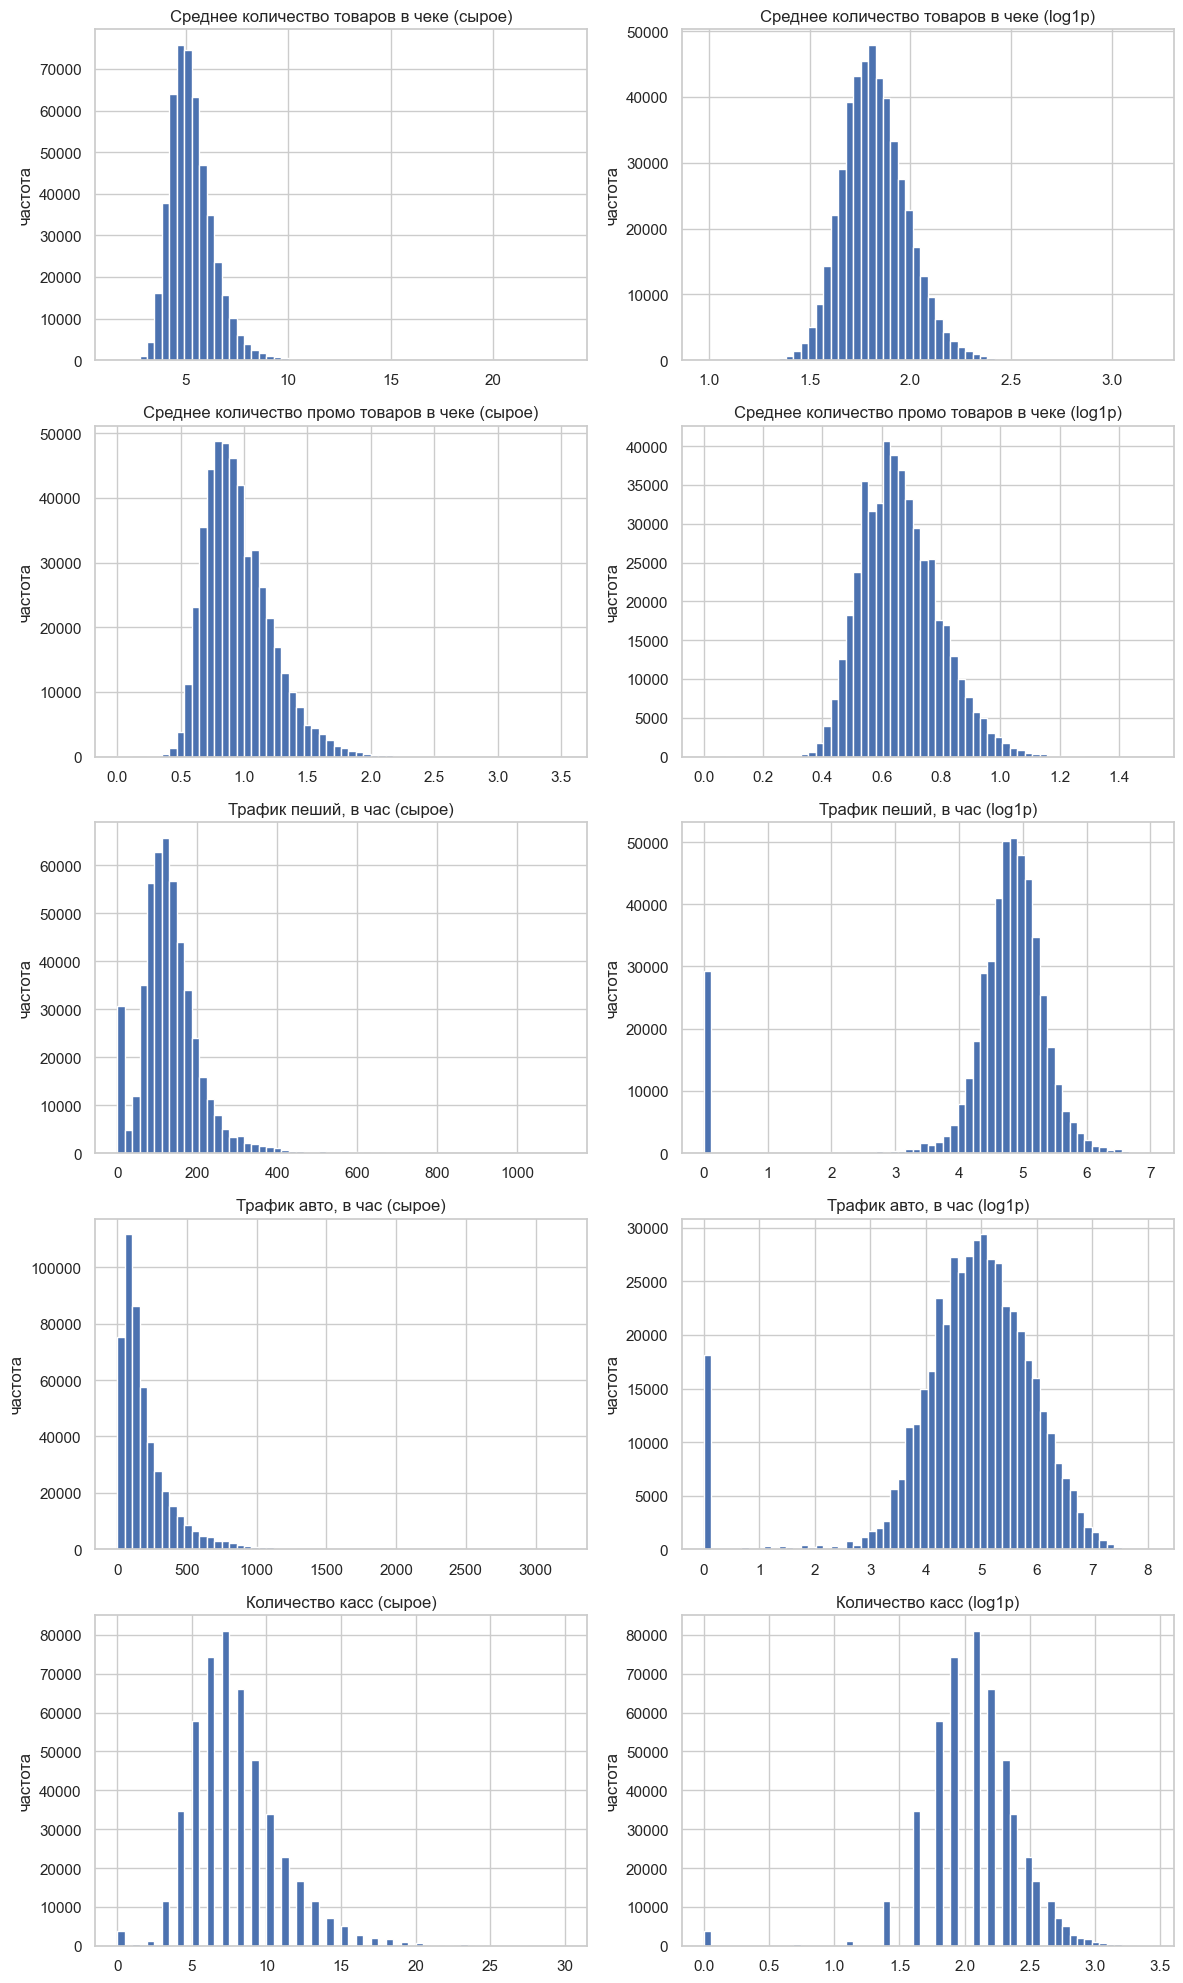

In [10]:
cols = [
    "Среднее количество товаров в чеке",
    "Среднее количество промо товаров в чеке",
    "Трафик пеший, в час",
    "Трафик авто, в час",
    "Количество касс",
]

available_cols = [c for c in cols if c in df.columns]
missing_cols = [c for c in cols if c not in df.columns]
if missing_cols:
    print("Не найдены колонки:", missing_cols)

if not available_cols:
    raise ValueError("Нет доступных колонок для построения графиков")

n_rows = len(available_cols)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))

if n_rows == 1:
    axes = np.array([axes])

for i, col in enumerate(available_cols):
    raw = df[col].dropna()
    axes[i, 0].hist(raw, bins=60)
    axes[i, 0].set_title(f"{col} (сырое)")
    axes[i, 0].set_ylabel("частота")

    axes[i, 1].hist(np.log1p(raw), bins=60)
    axes[i, 1].set_title(f"{col} (log1p)")
    axes[i, 1].set_ylabel("частота")

plt.tight_layout()
plt.show()